# 多层感知机的从零开始实现

## 环境配置


In [1]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
import os
import sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    from torch import nn
    import torch_npu

warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="Cannot create tensor")
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()

from src.utils import load_data_fashion_mnist, train_epoch_ch3, train_ch3, evaluate_accuracy, Animator, set_axes, plot, use_svg_display
import numpy as np
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png")


def npu_iter(dl):
    for X, y in dl:
        yield X.to(device), y.to(device)


## 练习4.2.1
在所有其他参数保持不变的情况下，更改超参数`num_hiddens`的值，并查看此超参数的变化对结果有何影响。确定此超参数的最佳值。

**解答：**
在实验的 [128, 256, 512] 三种取值中，num_hiddens=256 在本超参数设置下效果最好。

以下使用 torch 编程进行验证：


In [2]:
import torch
from torch import nn
train_iter, test_iter = load_data_fashion_mnist(256, resize=None)

def initweight4_2_1(num_inputs=784, num_outputs=10, num_hiddens=256):
    W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens, device=device) * 0.01)
    b1 = nn.Parameter(torch.zeros(num_hiddens, device=device))
    W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs, device=device) * 0.01)
    b2 = nn.Parameter(torch.zeros(num_outputs, device=device))
    params = [W1, b1, W2, b2]
    return W1, b1, W2, b2, params

loss = nn.CrossEntropyLoss(reduction='none')


使用 `PyPTO` 编程进行验证:


In [3]:
from src.utils import load_data_fashion_mnist, Animator
from src.pypto_ops import PyPTOLinear, PyPTOReLU, PyPTOSoftmaxCrossEntropyLossFunction

train_iter, test_iter = load_data_fashion_mnist(256, resize=None)


def build_mlp(dims):
    """按维度列表 [784, h1, ..., 10] 构造 MLP：每层 PyPTOLinear，隐藏层后接 PyPTOReLU。"""
    layers = [nn.Flatten()]
    for i in range(len(dims) - 1):
        layers.append(PyPTOLinear(dims[i], dims[i + 1]))
        if i < len(dims) - 2:
            layers.append(PyPTOReLU())
    return nn.Sequential(*layers).to(device)

def loss_ce_none(y_hat, y):
    """逐样本交叉熵（reduction='none'），前向/反向均在 NPU 上计算。"""
    return PyPTOSoftmaxCrossEntropyLossFunction.apply(y_hat, y, 10)

def train_epoch_npu(net, train_iter, updater):
    """在 NPU 上训练一个迭代周期，返回 (平均损失, 训练准确率)。指标在设备上累加，每 epoch 仅同步一次。"""
    net.train()
    loss_sum = torch.zeros((), device=device)
    acc_sum = torch.zeros((), device=device)
    n = 0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss_ce_none(y_hat, y)
        updater.zero_grad()
        l.mean().backward()
        updater.step()
        loss_sum += l.detach().sum()
        acc_sum += (y_hat.detach().argmax(dim=1) == y).sum()
        n += y.numel()
    return loss_sum.item() / n, acc_sum.item() / n

def evaluate_accuracy_npu(net, data_iter):
    net.eval()
    acc_sum = torch.zeros((), device=device)
    n = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            acc_sum += (net(X).argmax(dim=1) == y).sum()
            n += y.numel()
    return acc_sum.item() / n


num_hiddens=128, train_loss=0.3914715494791667, train_acc=0.86175, test_acc=0.8492
num_hiddens=256, train_loss=0.38418323567708335, train_acc=0.8649833333333333, test_acc=0.8497
num_hiddens=512, train_loss=0.3784591471354167, train_acc=0.8677666666666667, test_acc=0.8381


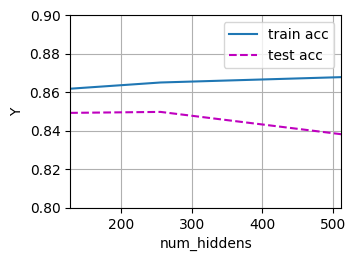

In [4]:
# 练习：不同隐藏单元数对结果的影响（NPU + pypto）
showtrain = 0  # showtrain=1 可展示每个配置的训练过程
num_hiddenslist = [128, 256, 512]
animatornum_hiddens = Animator(xlabel='num_hiddens', ylabel='Y',
                               xlim=[num_hiddenslist[0], num_hiddenslist[-1]], ylim=[0.8, 0.9],
                               legend=['train acc', 'test acc'])
results = []
for num_hiddens in num_hiddenslist:
    num_epochs, lr = 10, 0.1
    torch.manual_seed(0)  # 固定随机种子：消除网格扫描中各配置随机初始化带来的锯齿状波动
    net = build_mlp([784, num_hiddens, 10])
    updater = torch.optim.SGD(net.parameters(), lr=lr)
    if showtrain == 1:
        animator = Animator(xlabel=f'epoch num_hiddens:{num_hiddens}', ylabel='Y',
                            xlim=[1, num_epochs], ylim=[0.25, 0.9],
                            legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_npu(net, train_iter, updater)
        test_acc = evaluate_accuracy_npu(net, test_iter)
        if showtrain == 1:
            animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    animatornum_hiddens.add(num_hiddens, (train_acc, test_acc))
    results.append((num_hiddens, train_loss, train_acc, test_acc))
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc
for num_hiddens, tl, ta, tt in results:
    print(f'num_hiddens' + '=' + str(num_hiddens) + ', train_loss=' + str(tl) + ', train_acc=' + str(ta) + ', test_acc=' + str(tt))


## 练习4.2.2
尝试添加更多的隐藏层，并查看它对结果有何影响。

**解答：**
在其他参数不变的情况下单纯增加隐藏层数会减少准确率。

以下使用 torch 编程进行验证：


num_hiddenlayers=1, train_loss=0.3855440619150797, train_acc=0.8629833333333333, test_acc=0.8529
num_hiddenlayers=2, train_loss=0.39532741355895995, train_acc=0.8571666666666666, test_acc=0.8496
num_hiddenlayers=3, train_loss=0.4688213047027588, train_acc=0.8320833333333333, test_acc=0.8312
num_hiddenlayers=4, train_loss=1.2994459696451823, train_acc=0.46136666666666665, test_acc=0.5713


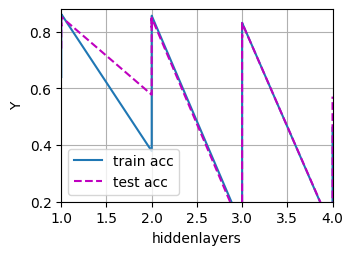

In [5]:
train_iter, test_iter = load_data_fashion_mnist(256, resize=None)

def initweight4_2_2(num_inputs=784, num_outputs=10, num_hiddens=256, num_hiddenlayers=1):
    params = []
    for i in range(num_hiddenlayers):
        a = num_inputs if i == 0 else num_hiddens
        b = num_hiddens
        params.append(nn.Parameter(torch.randn(a, b, device=device) * 0.01))
        params.append(nn.Parameter(torch.zeros(b, device=device)))
    params.append(nn.Parameter(torch.randn(num_hiddens, num_outputs, device=device) * 0.01))
    params.append(nn.Parameter(torch.zeros(num_outputs, device=device)))
    return params

showtrain = 0
num_inputs = 784
num_outputs = 10
num_hiddens = 256
num_hiddenlayerslist = list(range(1, 5))
animatornum_hiddenlayers = Animator(xlabel='hiddenlayers', ylabel='Y',
                                     xlim=[num_hiddenlayerslist[0], num_hiddenlayerslist[-1]], ylim=[0.2, 0.88],
                                     legend=['train acc', 'test acc'])
results = []
for num_hiddenlayers in num_hiddenlayerslist:
    num_epochs, lr = 10, 0.1
    torch.manual_seed(0)  # 固定随机种子：消除网格扫描中各配置随机初始化带来的锯齿状波动
    loss = nn.CrossEntropyLoss(reduction='none')
    params = initweight4_2_2(num_inputs=num_inputs, num_outputs=num_outputs,
                              num_hiddens=num_hiddens, num_hiddenlayers=num_hiddenlayers)
    updater = torch.optim.SGD(params, lr=lr)
    def relu(X):
        a = torch.zeros_like(X)
        return torch.max(X, a)
    def net(X):
        X = X.reshape((-1, num_inputs))
        H = relu(X@params[0] + params[1])
        for i in range(2, 2 * num_hiddenlayers, 2):
            H = relu(H@(params[i]) + params[i + 1])
        return (H@(params[-2]) + params[-1])
    if showtrain == 1:
        animator = Animator(xlabel=f'epoch num_hiddenlayers:{num_hiddenlayers}', ylabel='Y',
                                xlim=[1, num_epochs], ylim=[0.25, 0.9],
                                legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, npu_iter(train_iter), loss, updater)
        test_acc = evaluate_accuracy(net, npu_iter(test_iter))
        if showtrain == 1:
            animator.add(epoch + 1, train_metrics + (test_acc,))
        train_loss, train_acc = train_metrics
        animatornum_hiddenlayers.add(num_hiddenlayers, (train_acc, test_acc))
    results.append((num_hiddenlayers, train_loss, train_acc, test_acc))
for num_hiddenlayers, tl, ta, tt in results:
    print(f'num_hiddenlayers' + '=' + str(num_hiddenlayers) + ', train_loss=' + str(tl) + ', train_acc=' + str(ta) + ', test_acc=' + str(tt))


使用 `PyPTO` 编程进行验证:


num_hiddenlayers=1, train_loss=0.38418323567708335, train_acc=0.8649833333333333, test_acc=0.8497
num_hiddenlayers=2, train_loss=0.3917651692708333, train_acc=0.85885, test_acc=0.8299
num_hiddenlayers=3, train_loss=0.46125533854166667, train_acc=0.8363, test_acc=0.8159


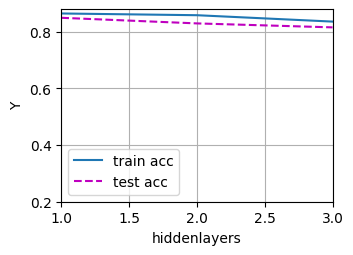

In [6]:
# 练习：不同隐藏层数对结果的影响（NPU + pypto）
showtrain = 0
num_hiddens = 256
num_hiddenlayerslist = list(range(1, 4))
animatornum_hiddenlayers = Animator(xlabel='hiddenlayers', ylabel='Y',
                                    xlim=[num_hiddenlayerslist[0], num_hiddenlayerslist[-1]], ylim=[0.2, 0.88],
                                    legend=['train acc', 'test acc'])
results = []
for num_hiddenlayers in num_hiddenlayerslist:
    num_epochs, lr = 10, 0.1
    torch.manual_seed(0)  # 固定随机种子：消除网格扫描中各配置随机初始化带来的锯齿状波动
    net = build_mlp([784] + [num_hiddens] * num_hiddenlayers + [10])
    updater = torch.optim.SGD(net.parameters(), lr=lr)
    if showtrain == 1:
        animator = Animator(xlabel=f'epoch num_hiddenlayers:{num_hiddenlayers}', ylabel='Y',
                            xlim=[1, num_epochs], ylim=[0.25, 0.9],
                            legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_npu(net, train_iter, updater)
        test_acc = evaluate_accuracy_npu(net, test_iter)
        if showtrain == 1:
            animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    animatornum_hiddenlayers.add(num_hiddenlayers, (train_acc, test_acc))
    results.append((num_hiddenlayers, train_loss, train_acc, test_acc))
for num_hiddenlayers, tl, ta, tt in results:
    print(f'num_hiddenlayers' + '=' + str(num_hiddenlayers) + ', train_loss=' + str(tl) + ', train_acc=' + str(ta) + ', test_acc=' + str(tt))


## 练习4.2.3
改变学习速率会如何影响结果？保持模型架构和其他超参数（包括轮数）不变，学习率设置为多少会带来最好的结果？

**解答：**
较大的学习速率可以让 loss 下降更快，但也可能造成参数更新值过大导致无法收敛。过小的学习率会要求更多的训练轮数。在实验的 lr=[0.01, 0.1, 0.5, 1.0] 中，lr=0.1 达到了最好的测试准确率。此外，使用随迭代周期指数衰减的学习率可以进一步稳定后期收敛。

以下使用 torch 编程进行验证：


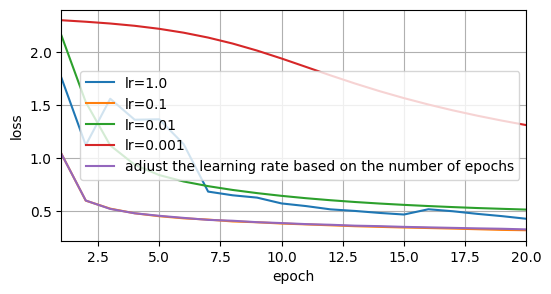

In [4]:
listlr = [1.0, 0.1, 0.01, 0.001]
train_iter, test_iter = load_data_fashion_mnist(256, resize=None)
num_epochs = 20
curves = []
for lr in listlr:
    num_inputs = 784
    num_outputs = 10
    num_hiddens = 256
    W1, b1, W2, b2, params = initweight4_2_1()
    updater = torch.optim.SGD(params, lr=lr)
    epoch_loss = []
    def relu(X):
        a = torch.zeros_like(X)
        return torch.max(X, a)
    def net(X):
        X = X.reshape((-1, num_inputs))
        H = relu(X@W1 + b1)
        return (H@W2 + b2)
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, npu_iter(train_iter), loss, updater)
        test_acc = evaluate_accuracy(net, npu_iter(test_iter))
        epoch_loss.append(train_metrics[0])
        train_loss, train_acc = train_metrics
    curves.append((f'lr={lr}', epoch_loss))

num_inputs = 784
num_outputs = 10
num_hiddens = 256
W1, b1, W2, b2, params = initweight4_2_1()
optimizer_ExpLR = torch.optim.SGD(params, lr=0.1)
scheduler_ExpLR = torch.optim.lr_scheduler.ExponentialLR(optimizer_ExpLR, gamma=0.98)
epoch_loss = []
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1)
    return (H@W2 + b2)
for epoch in range(num_epochs):
    train_metrics = train_epoch_ch3(net, npu_iter(train_iter), loss, optimizer_ExpLR)
    scheduler_ExpLR.step()
    test_acc = evaluate_accuracy(net, npu_iter(test_iter))
    epoch_loss.append(train_metrics[0])
    train_loss, train_acc = train_metrics
curves.append(('adjust the learning rate based on the number of epochs', epoch_loss))

# 绘制训练曲线（与主 notebook 一致的 d2l 风格）
plot(torch.arange(1, num_epochs + 1), [l for _, l in curves], 'epoch', 'loss',
     legend=[lab for lab, _ in curves], xlim=[1, num_epochs], figsize=(6, 3))


使用 `PyPTO` 编程进行验证:


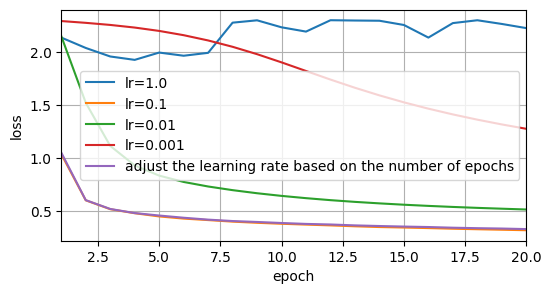

In [5]:
# 练习：不同学习率 + 指数衰减策略对训练损失的影响（NPU + pypto）
num_epochs = 20
listlr = [1.0, 0.1, 0.01, 0.001]
train_iter, test_iter = load_data_fashion_mnist(256, resize=None)
curves = []
for lr in listlr:
    net = build_mlp([784, 256, 10])
    updater = torch.optim.SGD(net.parameters(), lr=lr)
    epoch_loss = []
    for epoch in range(num_epochs):
        train_metrics = train_epoch_npu(net, train_iter, updater)
        test_acc = evaluate_accuracy_npu(net, test_iter)
        epoch_loss.append(train_metrics[0])
    train_loss, train_acc = train_metrics
    curves.append((f'lr={lr}', epoch_loss))
# 指数衰减策略
net = build_mlp([784, 256, 10])
optimizer_ExpLR = torch.optim.SGD(net.parameters(), lr=0.1)
scheduler_ExpLR = torch.optim.lr_scheduler.ExponentialLR(optimizer_ExpLR, gamma=0.98)
epoch_loss = []
for epoch in range(num_epochs):
    train_metrics = train_epoch_npu(net, train_iter, optimizer_ExpLR)
    scheduler_ExpLR.step()
    test_acc = evaluate_accuracy_npu(net, test_iter)
    epoch_loss.append(train_metrics[0])
curves.append(('adjust the learning rate based on the number of epochs', epoch_loss))

# 绘制训练曲线（与主 notebook 一致的 d2l 风格）
plot(torch.arange(1, num_epochs + 1), [l for _, l in curves], 'epoch', 'loss',
     legend=[lab for lab, _ in curves], xlim=[1, num_epochs], figsize=(6, 3))


## 练习4.2.4
通过对所有超参数（学习率、轮数、隐藏层数、每层的隐藏单元数）进行联合优化，可以得到的最佳结果是什么？

**解答：**

一层隐藏层结果如下：

<table style="margin-left: 0; margin-right: auto; width: auto; text-align: left;">
  <tr>
    <th style="padding: 8px; text-align: left;">num_epochs</th>
    <th style="padding: 8px; text-align: left;">batch_size</th>
    <th style="padding: 8px; text-align: left;">lr</th>
    <th style="padding: 8px; text-align: left;">num_hiddens</th>
    <th style="padding: 8px; text-align: left;">test_acc</th>
    <th style="padding: 8px; text-align: left;">train_acc</th>
    <th style="padding: 8px; text-align: left;">train_loss</th>
  </tr>
  <tr>
    <td style="padding: 8px;">10</td>
    <td style="padding: 8px;">256</td>
    <td style="padding: 8px;">0.1</td>
    <td style="padding: 8px;">32</td>
    <td style="padding: 8px;">0.8459</td>
    <td style="padding: 8px;">0.854367</td>
    <td style="padding: 8px;">0.41196403</td>
  </tr>
  <tr>
    <td style="padding: 8px;">10</td>
    <td style="padding: 8px;">128</td>
    <td style="padding: 8px;">0.1</td>
    <td style="padding: 8px;">256</td>
    <td style="padding: 8px;">0.8629</td>
    <td style="padding: 8px;">0.8808833</td>
    <td style="padding: 8px;">0.33219405</td>
  </tr>
  <tr>
    <td style="padding: 8px;">10</td>
    <td style="padding: 8px;">64</td>
    <td style="padding: 8px;">0.1</td>
    <td style="padding: 8px;">256</td>
    <td style="padding: 8px;">0.8769</td>
    <td style="padding: 8px;">0.89346</td>
    <td style="padding: 8px;">0.291003041</td>
  </tr>
  <tr>
    <td style="padding: 8px;">10</td>
    <td style="padding: 8px;">32</td>
    <td style="padding: 8px;">0.1</td>
    <td style="padding: 8px;">256</td>
    <td style="padding: 8px;">0.8865</td>
    <td style="padding: 8px;">0.9014</td>
    <td style="padding: 8px;">0.26649176</td>
  </tr>
  <tr>
    <td style="padding: 8px;">10</td>
    <td style="padding: 8px;">16</td>
    <td style="padding: 8px;">0.1</td>
    <td style="padding: 8px;">512</td>
    <td style="padding: 8px;">0.8824</td>
    <td style="padding: 8px;">0.90453</td>
    <td style="padding: 8px;">0.2544131</td>
  </tr>
</table>

最佳结果（单层隐藏层）：

以下使用 torch 编程进行验证：


epochs=10, num_hiddens=256, lr=0.1, batch_size=32, train_loss=0.2652077939808369, train_acc=0.9022, test_acc=0.8809
epochs=10, num_hiddens=512, num_hiddens2=256, lr=0.1, batch_size=256, train_loss=0.38687478154500327, train_acc=0.8600333333333333, test_acc=0.8505


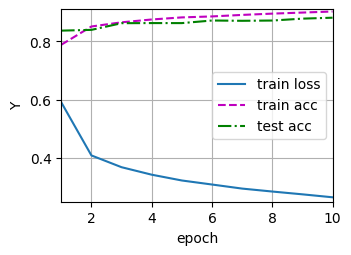

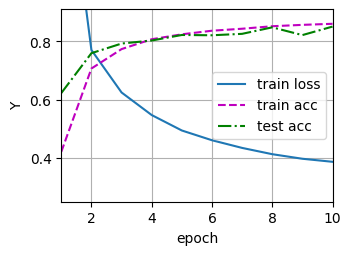

In [9]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256
num_epochs, lr, batch_size = 10, 0.1, 32
torch.manual_seed(0)  # 固定随机种子：消除网格扫描中各配置随机初始化带来的锯齿状波动
loss = nn.CrossEntropyLoss(reduction='none')
W1, b1, W2, b2, params = initweight4_2_1(num_inputs=num_inputs, num_outputs=num_outputs, num_hiddens=num_hiddens)
updater = torch.optim.SGD(params, lr=lr)
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1)
    return (H@W2 + b2)
train_iter, test_iter = load_data_fashion_mnist(batch_size)
animator = Animator(xlabel='epoch', ylabel='Y', xlim=[1, num_epochs], ylim=[0.25, 0.91],
                     legend=['train loss', 'train acc', 'test acc'])
results21 = []
for epoch in range(num_epochs):
    train_metrics = train_epoch_ch3(net, npu_iter(train_iter), loss, updater)
    test_acc = evaluate_accuracy(net, npu_iter(test_iter))
    animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
results21.append((num_epochs, num_hiddens, lr, batch_size, train_loss, train_acc, test_acc))
assert train_loss < 0.5, train_loss
assert train_acc <= 1 and train_acc > 0.7, train_acc
assert test_acc <= 1 and test_acc > 0.7, test_acc

def initweight4_2_4(num_inputs=784, num_outputs=10, num_hiddens=256):
    num_hiddens2 = int(num_hiddens / 2) if (num_hiddens / 2) > 10 else 10
    W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens, device=device) * 0.01)
    b1 = nn.Parameter(torch.zeros(num_hiddens, device=device))
    W2 = nn.Parameter(torch.randn(num_hiddens, num_hiddens2, device=device) * 0.01)
    b2 = nn.Parameter(torch.zeros(num_hiddens2, device=device))
    W3 = nn.Parameter(torch.randn(num_hiddens2, num_outputs, device=device) * 0.01)
    b3 = nn.Parameter(torch.zeros(num_outputs, device=device))
    params = [W1, b1, W2, b2, W3, b3]
    return W1, b1, W2, b2, W3, b3, params

num_inputs, num_outputs, num_hiddens = 784, 10, 512
num_hiddens2 = int(num_hiddens / 2) if (num_hiddens / 2) > 10 else 10
num_epochs, lr, batch_size = 10, 0.1, 256
torch.manual_seed(0)  # 固定随机种子
loss = nn.CrossEntropyLoss(reduction='none')
W1, b1, W2, b2, W3, b3, params = initweight4_2_4(num_inputs=num_inputs, num_outputs=num_outputs, num_hiddens=num_hiddens)
updater = torch.optim.SGD(params, lr=lr)
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1)
    X2 = H@W2 + b2
    H2 = relu(X2)
    return (H2@W3 + b3)
train_iter, test_iter = load_data_fashion_mnist(batch_size)
animator = Animator(xlabel='epoch', ylabel='Y', xlim=[1, num_epochs], ylim=[0.25, 0.91],
                     legend=['train loss', 'train acc', 'test acc'])
for epoch in range(num_epochs):
    train_metrics = train_epoch_ch3(net, npu_iter(train_iter), loss, updater)
    test_acc = evaluate_accuracy(net, npu_iter(test_iter))
    animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
results21.append((num_epochs, num_hiddens, num_hiddens2, lr, batch_size, train_loss, train_acc, test_acc))
assert train_loss < 0.5, train_loss
assert train_acc <= 1 and train_acc > 0.7, train_acc
assert test_acc <= 1 and test_acc > 0.7, test_acc


for r in results21:
    if len(r) == 7:
        ne, nh, lr_, bs, tl, ta, tt = r
        print(f'epochs={ne}, num_hiddens={nh}, lr={lr_}, batch_size={bs}, train_loss={tl}, train_acc={ta}, test_acc={tt}')
    else:
        ne, nh, nh2, lr_, bs, tl, ta, tt = r
        print(f'epochs={ne}, num_hiddens={nh}, num_hiddens2={nh2}, lr={lr_}, batch_size={bs}, train_loss={tl}, train_acc={ta}, test_acc={tt}')


使用 `PyPTO` 编程进行验证:


epochs=10, num_hiddens=256, lr=0.1, batch_size=32, train_loss=0.26743028971354166, train_acc=0.9014333333333333, test_acc=0.8787


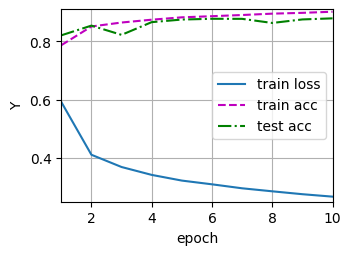

In [10]:
# 练习：较小批量（batch_size=32）下的训练（NPU + pypto）
num_epochs, lr = 10, 0.1
batch_size = 32
num_hiddens = 256
net = build_mlp([784, num_hiddens, 10])
updater = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = load_data_fashion_mnist(batch_size)
animator = Animator(xlabel='epoch', ylabel='Y', xlim=[1, num_epochs], ylim=[0.25, 0.91],
                    legend=['train loss', 'train acc', 'test acc'])
for epoch in range(num_epochs):
    train_metrics = train_epoch_npu(net, train_iter, updater)
    test_acc = evaluate_accuracy_npu(net, test_iter)
    animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
assert train_loss < 1.0, train_loss
assert train_acc <= 1 and train_acc > 0.6, train_acc
assert test_acc <= 1 and test_acc > 0.6, test_acc
print(f'epochs={num_epochs}, num_hiddens={num_hiddens}, lr={lr}, batch_size={batch_size}, train_loss={train_loss}, train_acc={train_acc}, test_acc={test_acc}')


两层隐藏层结果如下：

<table style="margin-left: 0; margin-right: auto; width: auto; text-align: left;">
  <tr>
    <th style="padding: 8px; text-align: left;">num_epochs</th>
    <th style="padding: 8px; text-align: left;">batch_size</th>
    <th style="padding: 8px; text-align: left;">lr</th>
    <th style="padding: 8px; text-align: left;">num_hiddens1</th>
    <th style="padding: 8px; text-align: left;">num_hiddens2</th>
    <th style="padding: 8px; text-align: left;">test_acc</th>
    <th style="padding: 8px; text-align: left;">train_acc</th>
    <th style="padding: 8px; text-align: left;">train_loss</th>
  </tr>
  <tr>
    <td style="padding: 8px;">10</td>
    <td style="padding: 8px;">256</td>
    <td style="padding: 8px;">0.1</td>
    <td style="padding: 8px;">512</td>
    <td style="padding: 8px;">256</td>
    <td style="padding: 8px;">0.8854</td>
    <td style="padding: 8px;">0.90515</td>
    <td style="padding: 8px;">0.24805</td>
  </tr>
  <tr>
    <td style="padding: 8px;">10</td>
    <td style="padding: 8px;">128</td>
    <td style="padding: 8px;">0.1</td>
    <td style="padding: 8px;">256</td>
    <td style="padding: 8px;">128</td>
    <td style="padding: 8px;">0.8822</td>
    <td style="padding: 8px;">0.9017166</td>
    <td style="padding: 8px;">0.25835</td>
  </tr>
  <tr>
    <td style="padding: 8px;">10</td>
    <td style="padding: 8px;">64</td>
    <td style="padding: 8px;">0.1</td>
    <td style="padding: 8px;">512</td>
    <td style="padding: 8px;">256</td>
    <td style="padding: 8px;">0.8811</td>
    <td style="padding: 8px;">0.90435</td>
    <td style="padding: 8px;">0.248654</td>
  </tr>
  <tr>
    <td style="padding: 8px;">10</td>
    <td style="padding: 8px;">32</td>
    <td style="padding: 8px;">0.1</td>
    <td style="padding: 8px;">512</td>
    <td style="padding: 8px;">256</td>
    <td style="padding: 8px;">0.8837</td>
    <td style="padding: 8px;">0.906683</td>
    <td style="padding: 8px;">0.2463282</td>
  </tr>
  <tr>
    <td style="padding: 8px;">10</td>
    <td style="padding: 8px;">16</td>
    <td style="padding: 8px;">0.1</td>
    <td style="padding: 8px;">512</td>
    <td style="padding: 8px;">256</td>
    <td style="padding: 8px;">0.8789</td>
    <td style="padding: 8px;">0.90626</td>
    <td style="padding: 8px;">0.24752787</td>
  </tr>
</table>

最佳结果（两层隐藏层）：

epochs=10, num_hiddens=512,num_hiddens2=256,lr=0.1, batch_size=256, train_loss=0.38630748697916667, train_acc=0.8611666666666666, test_acc=0.8411


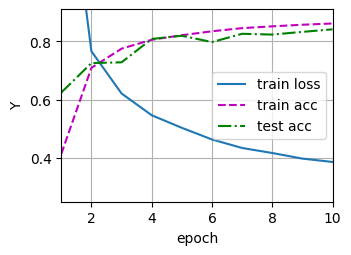

In [11]:
# 练习：更深的两隐藏层网络（512 -> 256 -> 10）（NPU + pypto）
num_hiddens = 512
num_hiddens2 = int(num_hiddens / 2) if (num_hiddens / 2) > 10 else 10
num_epochs, lr, batch_size = 10, 0.1, 256
net = build_mlp([784, num_hiddens, num_hiddens2, 10])
updater = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = load_data_fashion_mnist(batch_size)
animator = Animator(xlabel='epoch', ylabel='Y', xlim=[1, num_epochs], ylim=[0.25, 0.91],
                    legend=['train loss', 'train acc', 'test acc'])
for epoch in range(num_epochs):
    train_metrics = train_epoch_npu(net, train_iter, updater)
    test_acc = evaluate_accuracy_npu(net, test_iter)
    animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
assert train_loss < 0.5, train_loss
assert train_acc <= 1 and train_acc > 0.7, train_acc
assert test_acc <= 1 and test_acc > 0.7, test_acc
print(f'epochs={num_epochs}, num_hiddens={num_hiddens},num_hiddens2={num_hiddens2},lr={lr}, batch_size={batch_size}, train_loss={train_loss}, train_acc={train_acc}, test_acc={test_acc}')


## 练习4.2.5
描述为什么涉及多个超参数更具挑战性。

**解答：**
超参数无法通过常规的优化手段确定，每次调整超参数要依据训练结果导致调整一次需要的成本很大，而过多的超参数将导致更多的参数组合，使得通过训练来确定好最优的超参数很困难。

## 练习4.2.6
如果想要构建多个超参数的搜索方法，请想出一个聪明的策略。

**解答：**
根据过往的经验选定好一组超参数，从调整后计算成本最小的参数入手确定好它的值以后，再去确定计算成本比它大一点的参数，一步确定一个超参数，最后得到所有超参数的值，然后重复之前步骤，直到结果满意为止。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
